Mean Squared Error: 2.505011008507039
R2 Score: 0.9136518558389264


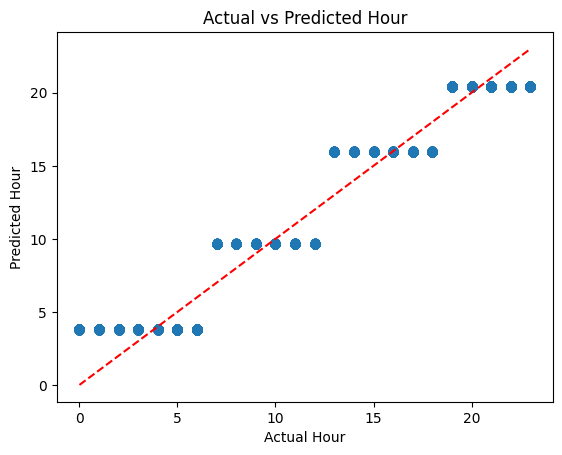

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("normalized_uber_data_enhanced (1).xlsx")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Convert categorical to numeric
df = pd.get_dummies(df, columns=["Time_Slot", "Day_of_Week"], drop_first=True)

# Features and target
X = df.drop(columns=["Hour", "Date", "Time"])
y = df["Hour"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Graph
plt.figure()

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.title("Actual vs Predicted Hour")
plt.xlabel("Actual Hour")
plt.ylabel("Predicted Hour")

plt.show()

Conclusion

The machine learning model performed well with an R² score of 0.91 and low Mean Squared Error. This indicates that the model can accurately predict ride timing based on the selected features, demonstrating the effectiveness of machine learning in analyzing time-based patterns in the dataset.

Insight 

The graph shows that most of the predicted values are close to the actual values, indicating that the model has learned the pattern effectively. The alignment of points along the diagonal line confirms that the model is making accurate predictions with minimal error.